# Initilization Cell

In [1]:
import xarray as xr                         #install xarray                     
import matplotlib.pyplot as plt             #install matplot
import cartopy.crs as ccrs                  #useful for plotting coastline
import cartopy.feature as cfeature
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
import gc
from scipy.interpolate import interp1d
from io import StringIO
import glob
import os
import earthaccess
auth = earthaccess.login(persist=True)

bbox = (-118, 32, -117, 33)  # west, south, east, north


# Data loading and formatting

In [2]:
AOP_CLIP_DIR = "granule_cache/aop_clipped"
PICKS_PATH = "chl_transect_picks.csv"

df = pd.read_csv(PICKS_PATH, parse_dates=["date"])
df = df.dropna(subset=["lat", "lon", "chl"]).reset_index(drop=True)

N_NEAREST = 10  # nearest pixels used per point


def latlon_to_xyz(lat, lon):
    lat_r, lon_r = np.radians(lat), np.radians(lon)
    return np.stack([np.cos(lat_r) * np.cos(lon_r),
                      np.cos(lat_r) * np.sin(lon_r),
                      np.sin(lat_r)], axis=-1)

#Reads the already-clipped AOP file
def get_clipped_granule(date_str):
    matches = glob.glob(os.path.join(AOP_CLIP_DIR, f"aop_clipped_{date_str}.nc"))
    if not matches:
        raise ValueError(f"No clipped AOP granule for {date_str} in {AOP_CLIP_DIR}")
    return xr.open_dataset(matches[0], chunks={})  # flat dataset (dims: y, x, wavelength)


west, south, east, north = bbox
records = []
for date_str, group_rows in df.groupby(df["date"].dt.strftime("%Y-%m-%d")):
    try:
        ds = get_clipped_granule(date_str)
    except ValueError as e:
        print(f"Skipping date {date_str}: {e}")
        continue
    lat_grid, lon_grid = ds["latitude"].values, ds["longitude"].values
    wavelengths = ds["wavelength"].values
    rrs_da = ds["Rrs"]
    mask = (lat_grid >= south) & (lat_grid <= north) & (lon_grid >= west) & (lon_grid <= east)
    ys, xs = np.where(mask)
    if len(ys) == 0:
        ds.close()
        continue
    xyz_grid = latlon_to_xyz(lat_grid[ys, xs], lon_grid[ys, xs])
    tree = cKDTree(xyz_grid)
    for idx, row in group_rows.iterrows():
        target_xyz = latlon_to_xyz(np.array([row["lat"]]), np.array([row["lon"]]))
        dist, flat_idx = tree.query(target_xyz, k=N_NEAREST)
        sel_y, sel_x = ys[flat_idx.ravel()], xs[flat_idx.ravel()]
        spectra = rrs_da.isel(
            y=xr.DataArray(sel_y, dims="pt"),
            x=xr.DataArray(sel_x, dims="pt"),
        ).values
        for rank, (d, spectrum) in enumerate(zip(dist.ravel() * 6371.0, spectra)):
            for wl, val in zip(wavelengths, spectrum):
                records.append({
                    "row_idx": idx, "group": row["group"], "date": row["date"],
                    "level": row["level"], "chl": row["chl"],
                    "pixel_rank": rank, "pixel_dist_km": d,
                    "wavelength": wl, "rrs": val,
                })
    ds.close()

rrs_long = pd.DataFrame(records)

df["chl_bin"] = df["level"] + "_chl"
no_pn_dates = pd.to_datetime(df.loc[df["group"] == "No PS but High CH", "date"].unique()).normalize()


Skipping date 2024-05-06: No clipped AOP granule for 2024-05-06 in granule_cache/aop_clipped


# Final calculation and df creation

In [3]:
def build_final_df(rl, df):
    rl = rl.copy()
    rl["date"] = pd.to_datetime(rl["date"]).dt.normalize()
    rl["chl_bin"] = rl["level"] + "_chl"

    ref_long = rl[rl["date"].isin(no_pn_dates)].copy()
    median_shape = (
        ref_long.groupby(["chl_bin", "wavelength"], as_index=False, observed=True)["rrs"]
                .median().rename(columns={"rrs": "rrs_median"}))

    point_rrs = (
        rl.groupby(["row_idx", "group", "date", "level", "chl", "wavelength"], as_index=False)
          ["rrs"].median())

    point_rrs = point_rrs.merge(df[["chl_bin"]], left_on="row_idx", right_index=True, how="left")
    point_rrs = point_rrs.merge(median_shape, on=["chl_bin", "wavelength"], how="left")
    point_rrs["aRrs"] = point_rrs["rrs"] - point_rrs["rrs_median"]

    return point_rrs.sort_values(["date", "row_idx", "wavelength"]).reset_index(drop=True)


final_df = build_final_df(rrs_long, df)
final_df

,row_idx,group,date,level,chl,wavelength,rrs,chl_bin,rrs_median,aRrs
0,0,No PS but High CH,2024-03-15,mid,1.905828,346.0,0.003959,mid_chl,-0.000024,0.003983
1,0,No PS but High CH,2024-03-15,mid,1.905828,348.0,0.004238,mid_chl,0.000176,0.004062
2,0,No PS but High CH,2024-03-15,mid,1.905828,351.0,0.004428,mid_chl,0.000360,0.004068
3,0,No PS but High CH,2024-03-15,mid,1.905828,353.0,0.004376,mid_chl,0.000370,0.004006
4,0,No PS but High CH,2024-03-15,mid,1.905828,356.0,0.004626,mid_chl,0.000506,0.004120
...,...,...,...,...,...,...,...,...,...,...
89607,521,No PS but High CH,2026-05-30,mid,1.823937,712.0,0.000110,mid_chl,0.000146,-0.000036
89608,521,No PS but High CH,2026-05-30,mid,1.823937,713.0,0.000102,mid_chl,0.000138,-0.000036
89609,521,No PS but High CH,2026-05-30,mid,1.823937,714.0,0.000092,mid_chl,0.000128,-0.000036
89610,521,No PS but High CH,2026-05-30,mid,1.823937,717.0,0.000038,mid_chl,0.000060,-0.000022


# Plotting 

Found 27 high-chl Known PS days: ['2024-04-29', '2024-05-07', '2024-07-31', '2024-12-16', '2024-12-17', '2024-12-18', '2024-12-19', '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-09', '2025-01-10', '2025-01-12', '2025-01-13', '2025-01-14', '2025-01-15', '2025-01-17', '2025-01-21', '2025-01-27', '2025-01-29', '2025-03-19', '2025-03-20', '2025-03-21', '2025-04-03', '2025-04-04', '2025-07-04', '2026-02-25']


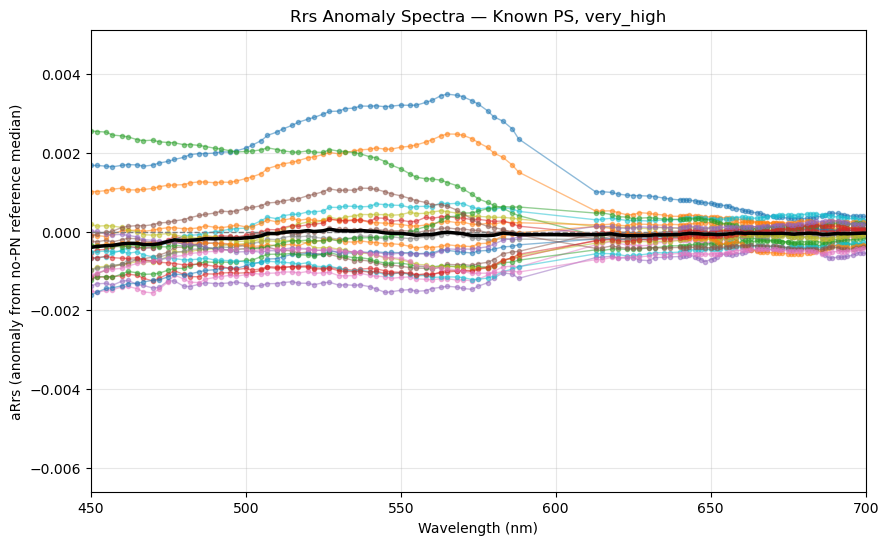

In [4]:
# All PN plotting code
# Define the level
level = "very_high"

# Filter to level selection of Known PS days
plot_df = final_df[
    (final_df["group"] == "Known PS") &
    (final_df["level"] == level)
].copy()

plot_df["date_str"] = plot_df["date"].dt.strftime("%Y-%m-%d")
dates = sorted(plot_df["date_str"].unique())
print(f"Found {len(dates)} high-chl Known PS days:", dates)

# Median spectrum across the days, per wavelength
median_spectrum = (
    plot_df.groupby("wavelength", as_index=False)["aRrs"]
           .mean()
           .sort_values("wavelength"))

fig, ax = plt.subplots(figsize=(10, 6))

# Individual day lines 
for date_str in dates:
    sub = plot_df[plot_df["date_str"] == date_str].sort_values("wavelength")
    ax.plot(sub["wavelength"], sub["aRrs"], marker="o", markersize=3,
             linewidth=1, alpha=0.5, label=date_str)

# Median line 
ax.plot(median_spectrum["wavelength"], median_spectrum["aRrs"],
         color="black", linewidth=2.5, label=f"Median ({len(dates)} days)", zorder=5)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("aRrs (anomaly from no-PN reference median)")
ax.set_xlim(450, 700)
ax.set_title(f"Rrs Anomaly Spectra — Known PS, {level}")
ax.grid(alpha=0.3)
plt.show()

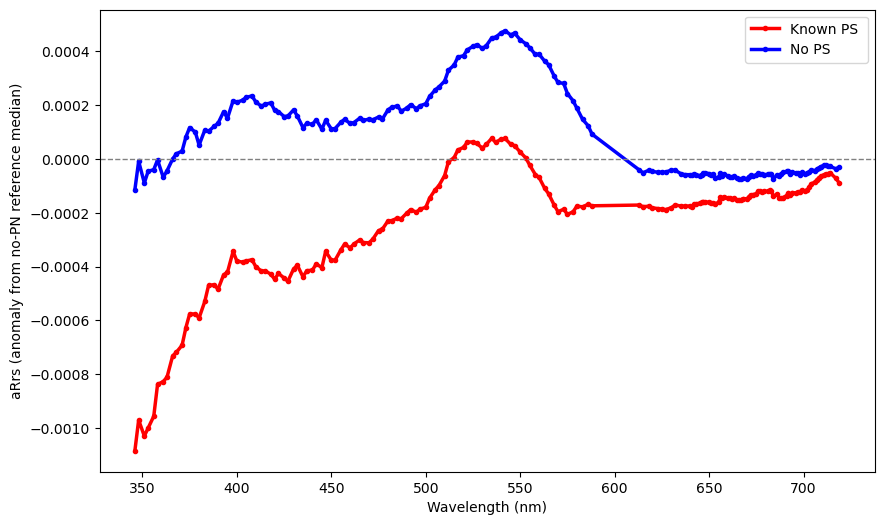

In [5]:

# Filter to high-chl days for both groups
ps_df = final_df[
    (final_df["group"] == "Known PS") &
    (final_df["level"] == "high")
].copy()

no_ps_df = final_df[
    (final_df["group"] == "No PS but High CH") &
    (final_df["level"] == "high")
].copy()

# Median aRrs spectrum per group, per wavelength
ps_median = (
    ps_df.groupby("wavelength", as_index=False)["aRrs"]
         .mean()
         .sort_values("wavelength"))

no_ps_median = (
    no_ps_df.groupby("wavelength", as_index=False)["aRrs"]
            .mean()
            .sort_values("wavelength"))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ps_median["wavelength"], ps_median["aRrs"],
        color="red", linewidth=2.5, marker="o", markersize=3,
        label="Known PS ")

ax.plot(no_ps_median["wavelength"], no_ps_median["aRrs"],
        color="blue", linewidth=2.5, marker="o", markersize=3,
        label="No PS ")

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("aRrs (anomaly from no-PN reference median)")
ax.legend()
plt.show()

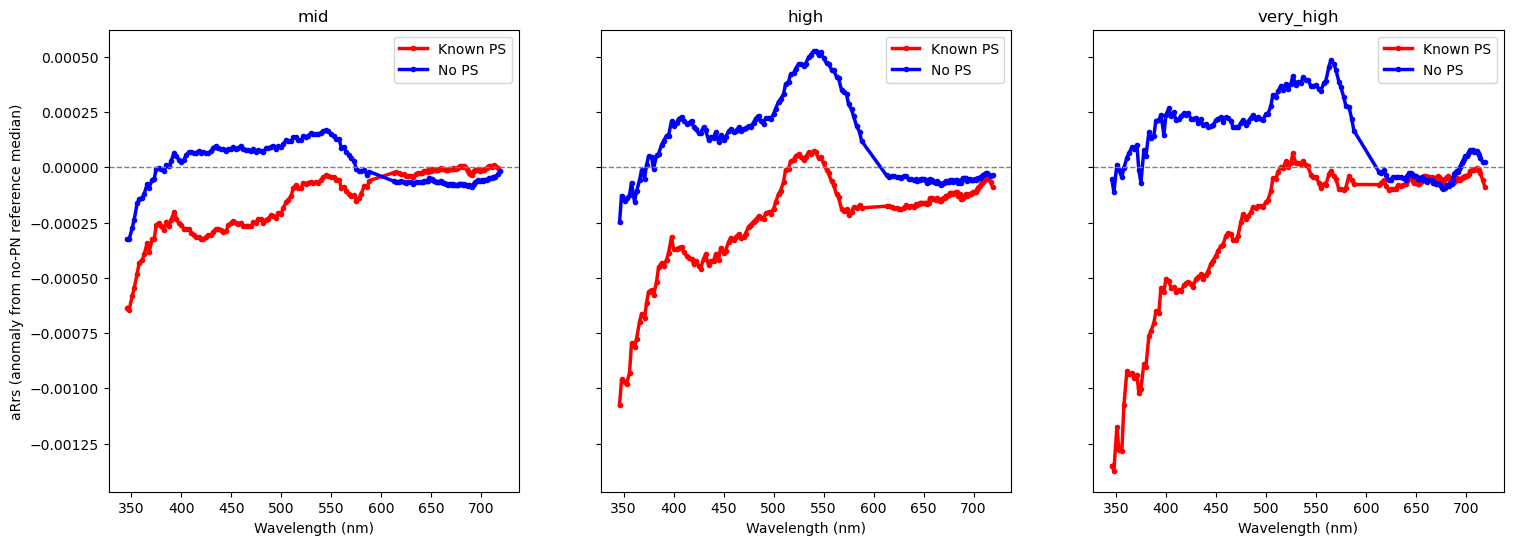

In [5]:

levels = ["mid", "high", "very_high"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, level in zip(axes, levels):
    ps_df = final_df[
        (final_df["group"] == "Known PS") &
        (final_df["level"] == level)
    ].copy()
    no_ps_df = final_df[
        (final_df["group"] == "No PS but High CH") &
        (final_df["level"] == level)
    ].copy()

    # Median aRrs spectrum per group, per wavelength
    ps_median = (
        ps_df.groupby("wavelength", as_index=False)["aRrs"]
             .mean()
             .sort_values("wavelength")
    )
    no_ps_median = (
        no_ps_df.groupby("wavelength", as_index=False)["aRrs"]
                .mean()
                .sort_values("wavelength")
    )

    ax.plot(ps_median["wavelength"], ps_median["aRrs"],
            color="red", linewidth=2.5, marker="o", markersize=3,
            label="Known PS")
    ax.plot(no_ps_median["wavelength"], no_ps_median["aRrs"],
            color="blue", linewidth=2.5, marker="o", markersize=3,
            label="No PS")

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(level)
    ax.set_xlabel("Wavelength (nm)")
    ax.legend()

axes[0].set_ylabel("aRrs (anomaly from no-PN reference median)")
plt.show()

# Stats 

Peak 1 wavelength: 542.0 nm
Trough wavelength : 545.0 nm
Peak 2 wavelength: 547.0 nm
R^2 = 0.0005, p-value = 0.8156, slope = -6.263e-12


/tmp/ipykernel_97/2832928365.py:88: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(flh_depth)


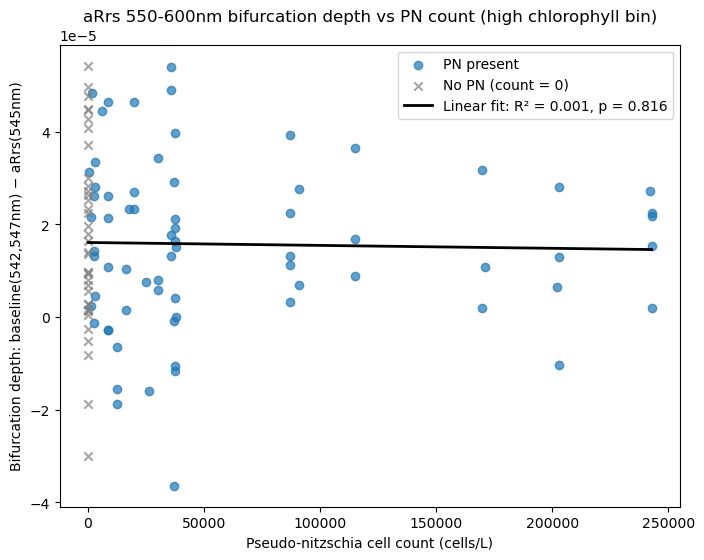

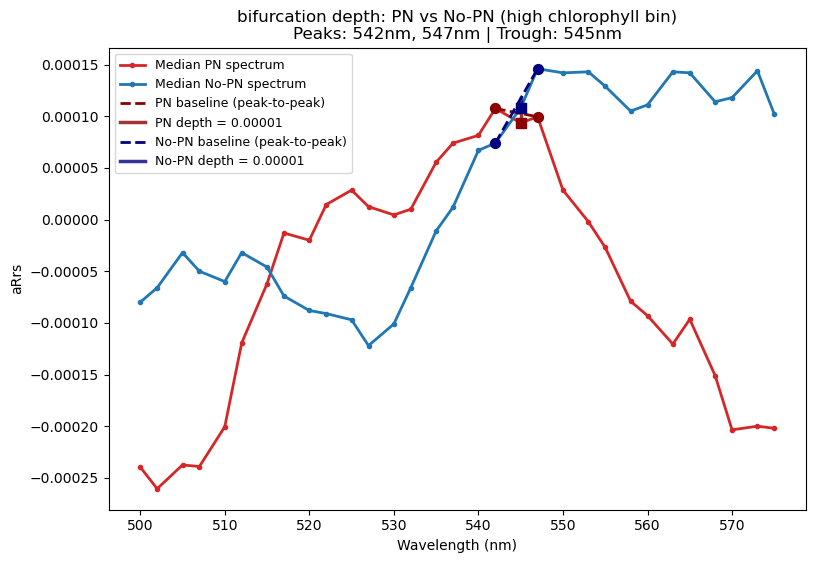

PN depth:    0.00001
No-PN depth: 0.00001
Difference (PN - No-PN): 0.00000


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.signal import find_peaks, argrelextrema

# chlorophyll bin to analyze - must match one of the pipeline's bin labels (low/mid/high/very_high)
CHL_BIN = "high"
bin_ids = df.index[df["level"] == CHL_BIN]
bin_label = f"{CHL_BIN} chlorophyll bin"

count_lookup = df["count"]

band_mask = (
    (final_df["wavelength"] >= 500)
    & (final_df["wavelength"] <= 575)
    & (final_df["row_idx"].isin(bin_ids))
)
band_df_all = final_df[band_mask]

# Build PN day spectrum in 550-600nm to locate the two shoulder peaks and the trough between them
pn_mask = band_mask & (final_df["row_idx"].map(count_lookup) > 0)
pn_band_df = final_df[pn_mask]

pn_spectrum = (
    pn_band_df.groupby("wavelength")["aRrs"]
    .median()
    .reset_index()
    .sort_values("wavelength")
    .reset_index(drop=True))

wl = pn_spectrum["wavelength"].values
vals = pn_spectrum["aRrs"].values

# Find local maxima (peaks) and minima (troughs) in the median PN spectrum
peak_idx, _ = find_peaks(vals)
trough_idx, _ = find_peaks(-vals)

# Take the two most prominent peaks (highest aRrs) and the trough located between them
peak_wls_sorted_by_height = wl[peak_idx][np.argsort(vals[peak_idx])[::-1]]
peak1_wl, peak2_wl = sorted(peak_wls_sorted_by_height[:2])

# Trough must sit between the two chosen peaks
between_mask = (wl[trough_idx] > peak1_wl) & (wl[trough_idx] < peak2_wl)
if not between_mask.any():
    raise ValueError("No trough found between the two selected peaks.")
trough_candidates = trough_idx[between_mask]
trough_wl = wl[trough_candidates][np.argmin(vals[trough_candidates])]

print(f"Peak 1 wavelength: {peak1_wl:.1f} nm")
print(f"Trough wavelength : {trough_wl:.1f} nm")
print(f"Peak 2 wavelength: {peak2_wl:.1f} nm")


# baseline subtraction, applied daily
def nearest_value(sub, target_wl):
    idx = (sub["wavelength"] - target_wl).abs().idxmin()
    return sub.loc[idx, "aRrs"]


def nearest_from_spectrum(spectrum_df, target_wl):
    """Same lookup as nearest_value, for use on a full median spectrum
    (pn_spectrum / no_pn_spectrum) instead of a per-row_idx subset."""
    idx = (spectrum_df["wavelength"] - target_wl).abs().idxmin()
    return spectrum_df.loc[idx, "aRrs"]


def flh_depth(sub):
    v1 = nearest_value(sub, peak1_wl)
    v2 = nearest_value(sub, peak2_wl)
    v_trough = nearest_value(sub, trough_wl)

    # Linear baseline between the two shoulder peaks, evaluated at trough_wl
    frac = (trough_wl - peak1_wl) / (peak2_wl - peak1_wl)
    baseline = v1 + frac * (v2 - v1)

    return pd.Series({
        "aRrs_peak1": v1,
        "aRrs_trough": v_trough,
        "aRrs_peak2": v2,
        "baseline_at_trough": baseline,
        "bifurcation_depth": baseline - v_trough,})


band_avg = (
    band_df_all
    .groupby("row_idx")
    .apply(flh_depth)
    .reset_index())


# Merge with PN counts and clean
reg_df = band_avg.merge(count_lookup, left_on="row_idx", right_index=True, how="left")
reg_df = reg_df.dropna(subset=["bifurcation_depth", "count"])

zero_mask = reg_df["count"] == 0

# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(reg_df["count"], reg_df["bifurcation_depth"])
r_squared = r_value ** 2
print(f"R^2 = {r_squared:.4f}, p-value = {p_value:.4g}, slope = {slope:.4g}")
x_fit = np.linspace(reg_df["count"].min(), reg_df["count"].max(), 200)
y_fit = slope * x_fit + intercept


# Plot xy scatterplot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    reg_df.loc[~zero_mask, "count"], reg_df.loc[~zero_mask, "bifurcation_depth"],
    c="tab:blue", alpha=0.7, label="PN present")
ax.scatter(
    reg_df.loc[zero_mask, "count"], reg_df.loc[zero_mask, "bifurcation_depth"],
    c="tab:gray", alpha=0.7, marker="x", label="No PN (count = 0)")

ax.plot(x_fit, y_fit, color="black", lw=2,
        label=f"Linear fit: R² = {r_squared:.3f}, p = {p_value:.3g}")

ax.set_xlabel("Pseudo-nitzschia cell count (cells/L)")
ax.set_ylabel(
    f"Bifurcation depth: baseline({peak1_wl:.0f},{peak2_wl:.0f}nm) − aRrs({trough_wl:.0f}nm)"
)
ax.set_title(f"aRrs 550-600nm bifurcation depth vs PN count ({bin_label})")
ax.legend()
plt.show()


# Zoomed in plot
no_pn_mask = band_mask & (final_df["row_idx"].map(count_lookup) == 0)
no_pn_band_df = final_df[no_pn_mask]

no_pn_spectrum = (
    no_pn_band_df.groupby("wavelength")["aRrs"]
    .median()
    .reset_index()
    .sort_values("wavelength")
    .reset_index(drop=True))


# PN group values at the three key wavelengths
pn_peak1_val = nearest_from_spectrum(pn_spectrum, peak1_wl)
pn_peak2_val = nearest_from_spectrum(pn_spectrum, peak2_wl)
pn_trough_val = nearest_from_spectrum(pn_spectrum, trough_wl)
pn_baseline_val = pn_peak1_val + (trough_wl - peak1_wl) / (peak2_wl - peak1_wl) * (pn_peak2_val - pn_peak1_val)
pn_depth = pn_baseline_val - pn_trough_val

# No-PN group values at the SAME three wavelengths
nopn_peak1_val = nearest_from_spectrum(no_pn_spectrum, peak1_wl)
nopn_peak2_val = nearest_from_spectrum(no_pn_spectrum, peak2_wl)
nopn_trough_val = nearest_from_spectrum(no_pn_spectrum, trough_wl)
nopn_baseline_val = nopn_peak1_val + (trough_wl - peak1_wl) / (peak2_wl - peak1_wl) * (nopn_peak2_val - nopn_peak1_val)
nopn_depth = nopn_baseline_val - nopn_trough_val

fig3, ax3 = plt.subplots(figsize=(9, 6))

# Median spectra
ax3.plot(pn_spectrum["wavelength"], pn_spectrum["aRrs"],
          color="tab:red", lw=2, marker="o", markersize=3, label="Median PN spectrum")
ax3.plot(no_pn_spectrum["wavelength"], no_pn_spectrum["aRrs"],
          color="tab:blue", lw=2, marker="o", markersize=3, label="Median No-PN spectrum")

# PN baseline + depth
ax3.plot([peak1_wl, peak2_wl], [pn_peak1_val, pn_peak2_val],
          color="darkred", lw=2, linestyle="--", label="PN baseline (peak-to-peak)")
ax3.plot([trough_wl, trough_wl], [pn_baseline_val, pn_trough_val],
          color="darkred", lw=2.5, alpha=0.8,
          label=f"PN depth = {pn_depth:.5f}")
ax3.scatter([peak1_wl, peak2_wl], [pn_peak1_val, pn_peak2_val],
             color="darkred", zorder=5, s=50)
ax3.scatter([trough_wl], [pn_trough_val],
             color="darkred", zorder=5, s=50, marker="s")

# No-PN baseline + depth
ax3.plot([peak1_wl, peak2_wl], [nopn_peak1_val, nopn_peak2_val],
          color="navy", lw=2, linestyle="--", label="No-PN baseline (peak-to-peak)")
ax3.plot([trough_wl, trough_wl], [nopn_baseline_val, nopn_trough_val],
          color="navy", lw=2.5, alpha=0.8,
          label=f"No-PN depth = {nopn_depth:.5f}")
ax3.scatter([peak1_wl, peak2_wl], [nopn_peak1_val, nopn_peak2_val],
             color="navy", zorder=5, s=50)
ax3.scatter([trough_wl], [nopn_trough_val],
             color="navy", zorder=5, s=50, marker="s")

ax3.set_xlabel("Wavelength (nm)")
ax3.set_ylabel("aRrs")
ax3.set_title(f"bifurcation depth: PN vs No-PN ({bin_label})\n"
              f"Peaks: {peak1_wl:.0f}nm, {peak2_wl:.0f}nm | Trough: {trough_wl:.0f}nm")

ax3.legend(fontsize=9)
plt.show()

print(f"PN depth:    {pn_depth:.5f}")
print(f"No-PN depth: {nopn_depth:.5f}")
print(f"Difference (PN - No-PN): {pn_depth - nopn_depth:.5f}")